In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import math

We collect the data

In [2]:
df = pd.read_csv("../data/uber.csv")

# Data Exploration

We read the data

In [3]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 200000 entries, 0 to 199999
Data columns (total 9 columns):
 #   Column             Non-Null Count   Dtype  
---  ------             --------------   -----  
 0   Unnamed: 0         200000 non-null  int64  
 1   key                200000 non-null  str    
 2   fare_amount        200000 non-null  float64
 3   pickup_datetime    200000 non-null  str    
 4   pickup_longitude   200000 non-null  float64
 5   pickup_latitude    200000 non-null  float64
 6   dropoff_longitude  199999 non-null  float64
 7   dropoff_latitude   199999 non-null  float64
 8   passenger_count    200000 non-null  int64  
dtypes: float64(5), int64(2), str(2)
memory usage: 23.4 MB


In [4]:
df.describe()

,Unnamed: 0,fare_amount,pickup_longitude,pickup_latitude,dropoff_longitude,dropoff_latitude,passenger_count
count,2.000000e+05,200000.000000,200000.000000,200000.000000,199999.000000,199999.000000,200000.000000
mean,2.771250e+07,11.359955,-72.527638,39.935885,-72.525292,39.923890,1.684535
std,1.601382e+07,9.901776,11.437787,7.720539,13.117408,6.794829,1.385997
min,1.000000e+00,-52.000000,-1340.648410,-74.015515,-3356.666300,-881.985513,0.000000
25%,1.382535e+07,6.000000,-73.992065,40.734796,-73.991407,40.733823,1.000000
50%,2.774550e+07,8.500000,-73.981823,40.752592,-73.980093,40.753042,1.000000
75%,4.155530e+07,12.500000,-73.967154,40.767158,-73.963658,40.768001,2.000000
max,5.542357e+07,499.000000,57.418457,1644.421482,1153.572603,872.697628,208.000000


In [5]:
df.shape

(200000, 9)

In [6]:
df.isnull().mean() * 100

Unnamed: 0           0.0000
key                  0.0000
fare_amount          0.0000
pickup_datetime      0.0000
pickup_longitude     0.0000
pickup_latitude      0.0000
dropoff_longitude    0.0005
dropoff_latitude     0.0005
passenger_count      0.0000
dtype: float64

In [7]:
df.isnull().sum()

Unnamed: 0           0
key                  0
fare_amount          0
pickup_datetime      0
pickup_longitude     0
pickup_latitude      0
dropoff_longitude    1
dropoff_latitude     1
passenger_count      0
dtype: int64

In [8]:
df.duplicated().sum()

0

Only 2 rows out of 2 lac is null, so better to drop it.

In [9]:
df.head()

,Unnamed: 0,key,fare_amount,pickup_datetime,pickup_longitude,pickup_latitude,dropoff_longitude,dropoff_latitude,passenger_count
0,24238194,2015-05-07 19:52:06.0000003,7.5,2015-05-07 19:52:06 UTC,-73.999817,40.738354,-73.999512,40.723217,1
1,27835199,2009-07-17 20:04:56.0000002,7.7,2009-07-17 20:04:56 UTC,-73.994355,40.728225,-73.994710,40.750325,1
2,44984355,2009-08-24 21:45:00.00000061,12.9,2009-08-24 21:45:00 UTC,-74.005043,40.740770,-73.962565,40.772647,1
3,25894730,2009-06-26 08:22:21.0000001,5.3,2009-06-26 08:22:21 UTC,-73.976124,40.790844,-73.965316,40.803349,3
4,17610152,2014-08-28 17:47:00.000000188,16.0,2014-08-28 17:47:00 UTC,-73.925023,40.744085,-73.973082,40.761247,5


Data Cleaning

In [10]:
df = df[
    (df["pickup_latitude"].between(-90, 90)) &
    (df["dropoff_latitude"].between(-90, 90)) &
    (df["pickup_longitude"].between(-180, 180)) &
    (df["dropoff_longitude"].between(-180, 180))
]

In [11]:
df = df[
    (df["pickup_latitude"] != 0) &
    (df["pickup_longitude"] != 0) &
    (df["dropoff_latitude"] != 0) &
    (df["dropoff_longitude"] != 0)
]

In [12]:
df.drop(columns=['Unnamed: 0' , 'key'] , inplace=True)

In [13]:
def haversine(lat1, lon1, lat2, lon2):
    R = 6371  # Earth radius in km

    lat1, lon1, lat2, lon2 = map(np.radians, [lat1, lon1, lat2, lon2])

    dlat = lat2 - lat1
    dlon = lon2 - lon1

    a = np.sin(dlat/2)**2 + np.cos(lat1) * np.cos(lat2) * np.sin(dlon/2)**2
    c = 2 * np.arcsin(np.sqrt(a))

    return R * c

In [14]:
df["distance_km"] = df.apply(
    lambda row: haversine(
        row["pickup_latitude"],
        row["pickup_longitude"],
        row["dropoff_latitude"],
        row["dropoff_longitude"]
    ),
    axis=1
)

In [15]:
df['pickup_datetime'] = pd.to_datetime(df['pickup_datetime'])

In [16]:
df['weekday'] = df['pickup_datetime'].dt.weekday

In [17]:
df['hour'] = df['pickup_datetime'].dt.hour

In [18]:
df["month"] = df["pickup_datetime"].dt.month

In [19]:
df['year'] = df['pickup_datetime'].dt.year

In [20]:
df['monthly_quarters'] = df['month'].map({1:'Q1',2:'Q1',3:'Q1',4:'Q2',5:'Q2',6:'Q2',7:'Q3',
                                      8:'Q3',9:'Q3',10:'Q4',11:'Q4',12:'Q4'})

In [21]:
df['Hourly_Segments'] = df.hour.map({0:'H1',1:'H1',2:'H1',3:'H1',4:'H2',5:'H2',6:'H2',7:'H2',8:'H3',
                                     9:'H3',10:'H3',11:'H3',12:'H4',13:'H4',14:'H4',15:'H4',16:'H5',
                                     17:'H5',18:'H5',19:'H5',20:'H6',21:'H6',22:'H6',23:'H6'})

In [22]:
def peak_hour(hour):
    if 7 <= hour <= 10 or 17 <= hour <= 20:
        return 1
    return 0

df["is_peak_hour"] = df["hour"].apply(peak_hour)

In [23]:
df["passenger_count"] = df["passenger_count"].clip(1, 6)

In [24]:
df[df["fare_amount"] == 0].value_counts().sum()

3

In [25]:
df = df[df["fare_amount"] > 0]

In [26]:
cols = [col for col in df.columns if col != "fare_amount"] + ['fare_amount']
df = df[cols]

In [27]:
df.columns

Index(['pickup_datetime', 'pickup_longitude', 'pickup_latitude',
       'dropoff_longitude', 'dropoff_latitude', 'passenger_count',
       'distance_km', 'weekday', 'hour', 'month', 'year', 'monthly_quarters',
       'Hourly_Segments', 'is_peak_hour', 'fare_amount'],
      dtype='str')

In [28]:
df.drop(columns=["pickup_datetime" , "hour" , "month" ] , inplace=True)

# Exploratory Data Analysis

In [29]:
num_cols = df.select_dtypes(include="number").columns.tolist()

In [30]:
cat_cols = df.select_dtypes(include=["object" , "string" , "category"]).columns.tolist()

In [31]:
df[num_cols].corr()

,pickup_longitude,pickup_latitude,dropoff_longitude,dropoff_latitude,passenger_count,distance_km,weekday,year,is_peak_hour,fare_amount
pickup_longitude,1.000000,-0.965027,0.952395,-0.961019,0.009885,0.145752,0.008008,0.013321,-0.002953,0.010992
pickup_latitude,-0.965027,1.000000,-0.966218,0.993183,-0.009260,-0.021032,-0.008588,-0.014627,0.002466,-0.008044
dropoff_longitude,0.952395,-0.966218,1.000000,-0.966601,0.009783,0.131017,0.008069,0.012671,-0.002838,0.009432
dropoff_latitude,-0.961019,0.993183,-0.966601,1.000000,-0.010042,-0.036438,-0.008649,-0.014259,0.002182,-0.008081
passenger_count,0.009885,-0.009260,0.009783,-0.010042,1.000000,0.004708,0.036166,0.006234,-0.017690,0.010962
distance_km,0.145752,-0.021032,0.131017,-0.036438,0.004708,1.000000,0.001999,-0.000094,-0.005071,0.036262
weekday,0.008008,-0.008588,0.008069,-0.008649,0.036166,0.001999,1.000000,0.006093,-0.103385,0.006581
year,0.013321,-0.014627,0.012671,-0.014259,0.006234,-0.000094,0.006093,1.000000,-0.008569,0.118686
is_peak_hour,-0.002953,0.002466,-0.002838,0.002182,-0.017690,-0.005071,-0.103385,-0.008569,1.000000,-0.034584
fare_amount,0.010992,-0.008044,0.009432,-0.008081,0.010962,0.036262,0.006581,0.118686,-0.034584,1.000000


                               Visualising Categorical Features:                                


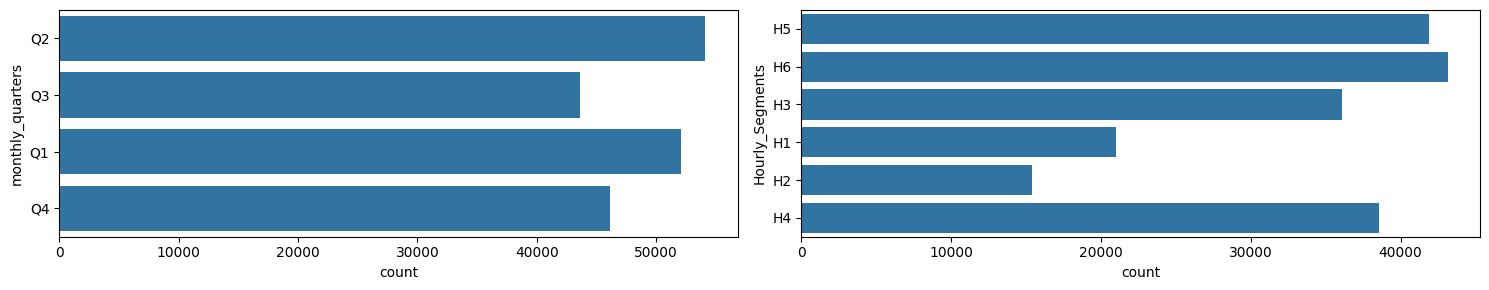

In [32]:
print('\033[1mVisualising Categorical Features:'.center(100))

n=2
plt.figure(figsize=[15,3*math.ceil(len(cat_cols)/n)])


for i in range(len(cat_cols)):
    if df[cat_cols[i]].nunique()<=12:
        plt.subplot(math.ceil(len(cat_cols)/n),n,i+1)
        sns.countplot(df[cat_cols[i]])
    else:
        plt.subplot(3,1,i-3)
        sns.countplot(df[cat_cols[i]])

plt.tight_layout()

In [33]:
df.groupby("Hourly_Segments")["fare_amount"].agg(["mean" , "max" , "median"])

,mean,max,median
Hourly_Segments,,,
H1,11.566446,171.35,8.9
H2,12.385019,499.00,8.1
H3,11.016089,230.00,8.1
H4,11.626489,220.00,8.5
H5,11.111463,200.00,8.5
H6,11.117842,206.38,8.5


In [34]:
df.groupby("monthly_quarters")['fare_amount'].agg(["mean" , "median"])

,mean,median
monthly_quarters,,
Q1,10.917741,8.1
Q2,11.516524,8.5
Q3,11.374455,8.5
Q4,11.599233,8.5


<Axes: xlabel='monthly_quarters', ylabel='fare_amount'>

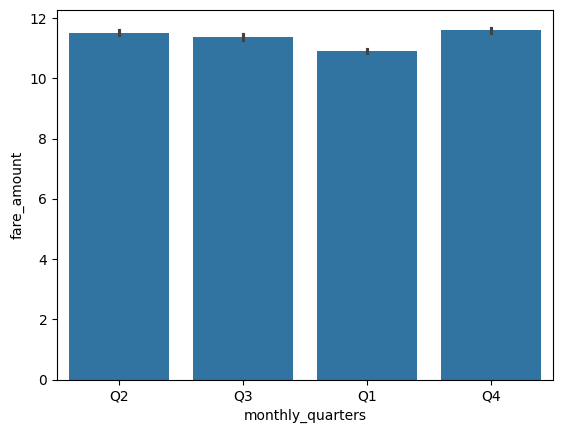

In [35]:
sns.barplot(x="monthly_quarters", y="fare_amount", data=df, estimator="mean")

<Axes: xlabel='Hourly_Segments', ylabel='fare_amount'>

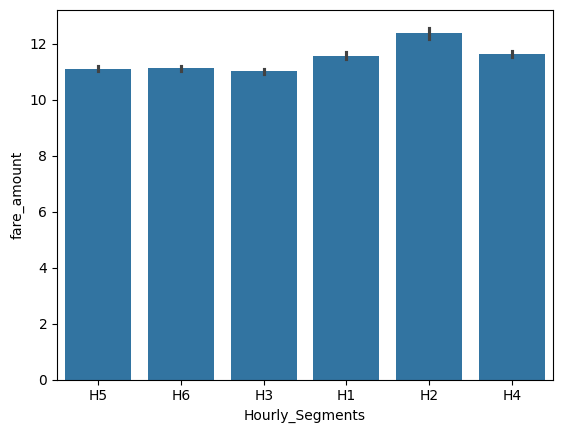

In [36]:
sns.barplot(x="Hourly_Segments", y="fare_amount", data=df, estimator="mean")

H2 segment is basically influenced by the outlier.

In [37]:
df.groupby(["monthly_quarters", "Hourly_Segments"])["fare_amount"].agg(["mean"])

mean
monthly_quarters Hourly_Segments           
Q1               H1               11.340777
                 H2               11.978977
                 H3               10.529831
                 H4               10.940095
                 H5               10.627979
                 H6               10.936437
Q2               H1               11.697680
                 H2               12.415742
                 H3               11.143528
                 H4               11.971141
                 H5               11.312212
                 H6               11.211231
Q3               H1               11.559465
                 H2               12.385856
                 H3               11.273798
                 H4               11.683457
                 H5               11.111842
                 H6               10.980982
Q4               H1               11.666405
                 H2               12.807100
                 H3               11.172588
                 H4               11.945961
                 H5               11.440314
                 H6               11.340041

H2 segment highly influence fare, it can be outlier also.

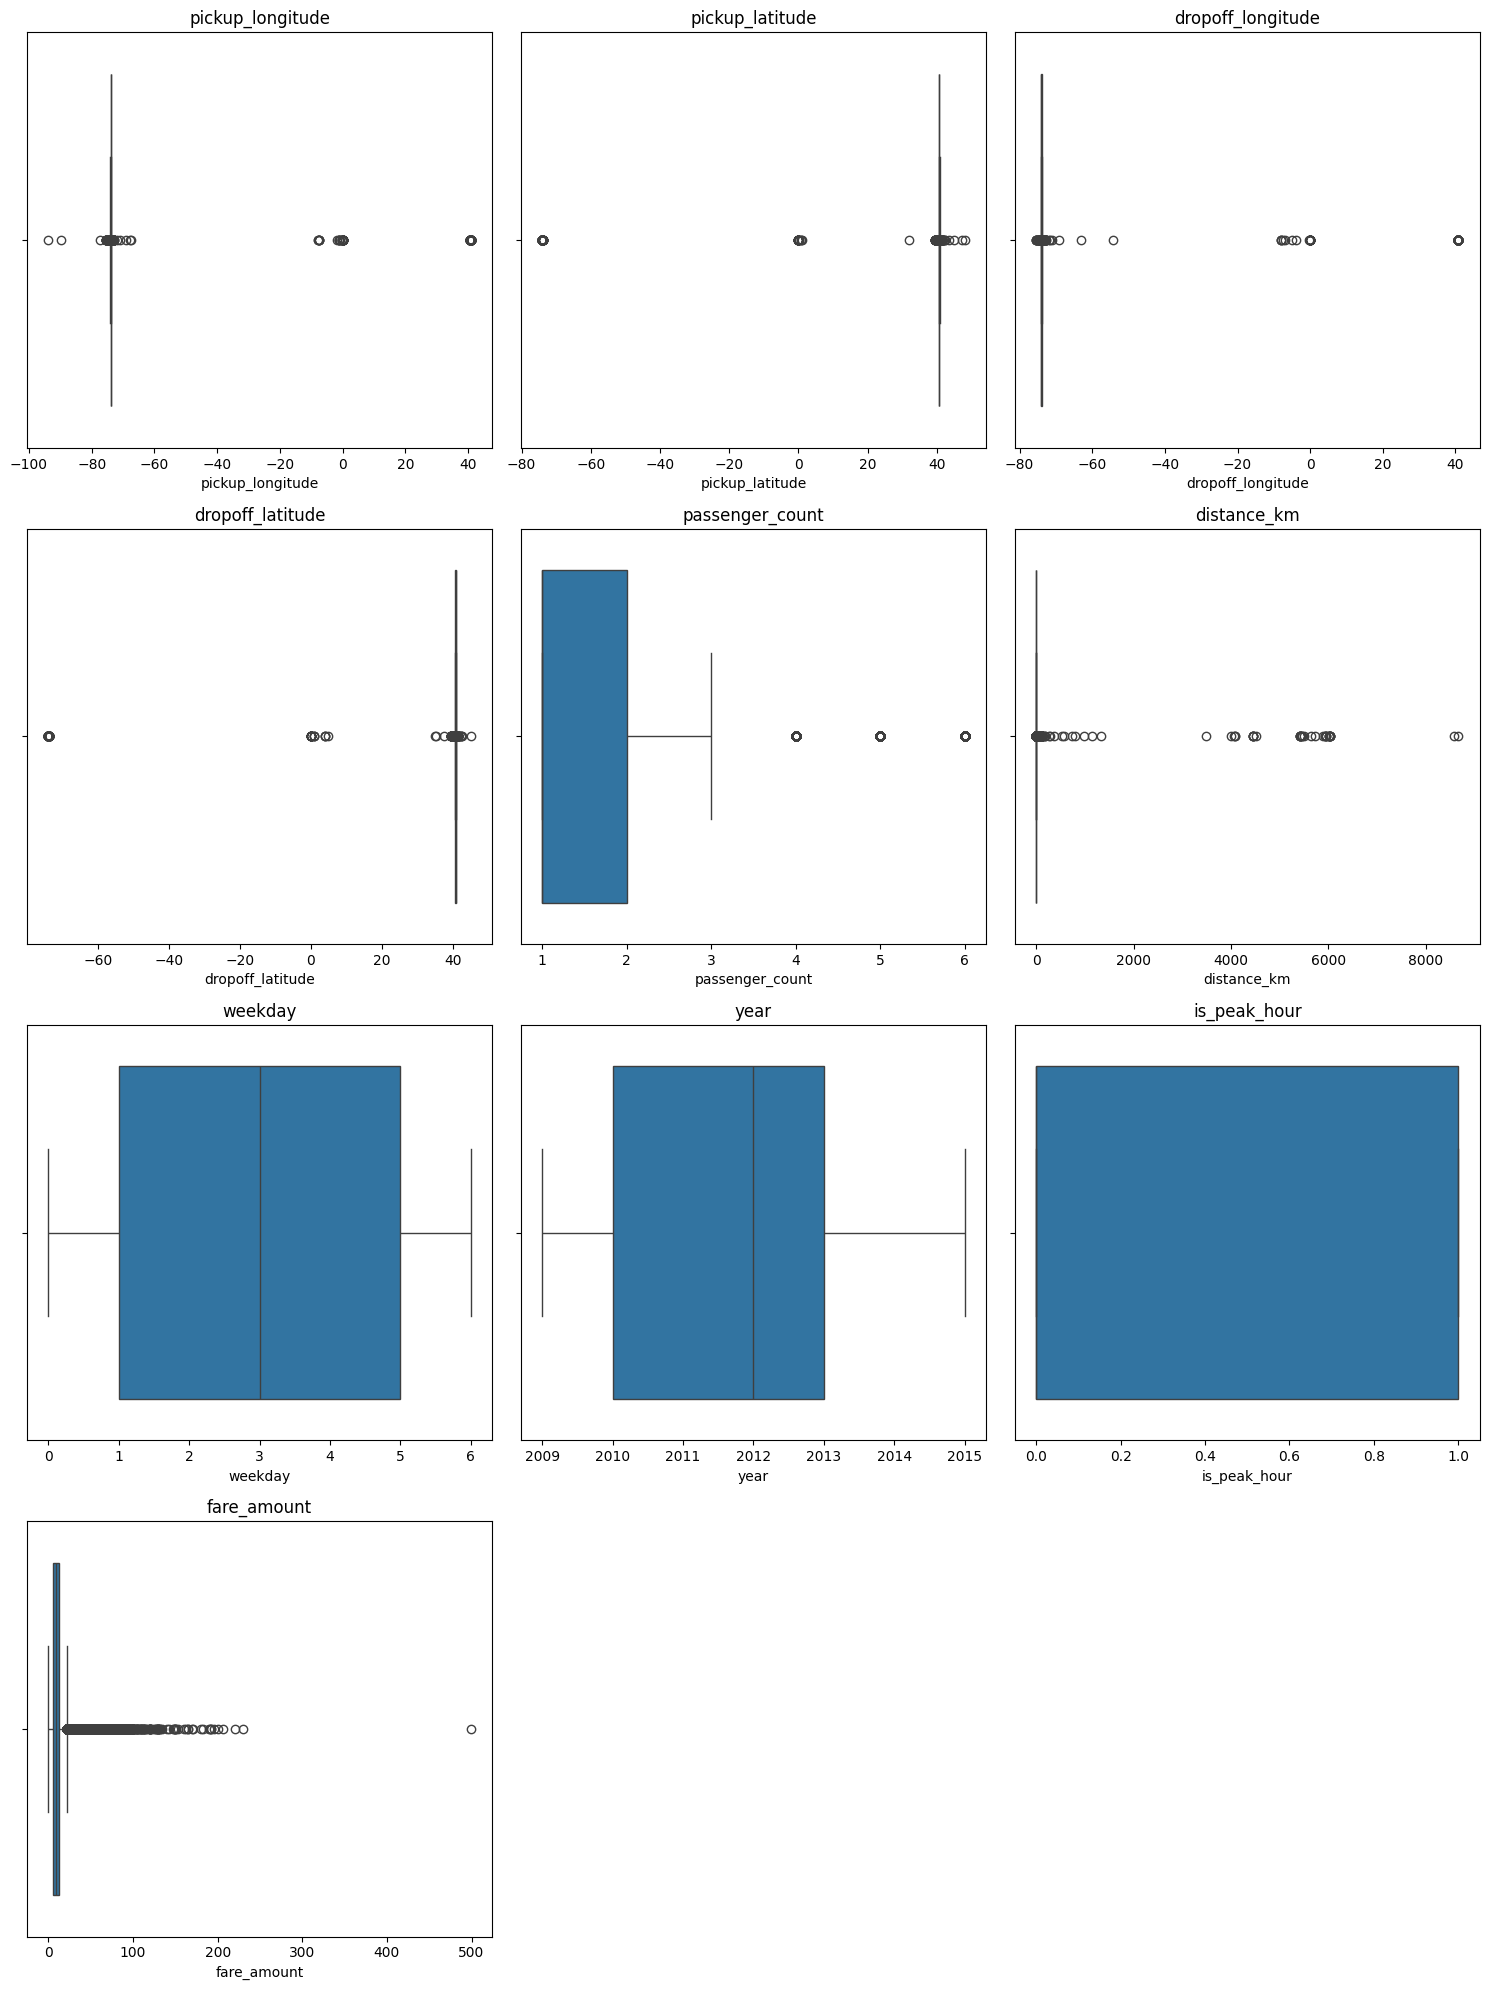

In [38]:
n_cols = 3 
n_rows = (len(num_cols) + n_cols - 1) // n_cols

plt.figure(figsize=(15, 5 * n_rows))

for i, col in enumerate(num_cols, 1):
    plt.subplot(n_rows, n_cols, i)
    sns.boxplot(x=df[col])
    plt.title(col)

plt.tight_layout()

In [39]:
df["fare_amount"].describe(percentiles=[0.90, 0.95, 0.99])

count    196000.000000
mean         11.345273
std           9.795865
min           0.010000
90%          20.500000
95%          30.250000
99%          52.540000
max         499.000000
Name: fare_amount, dtype: float64

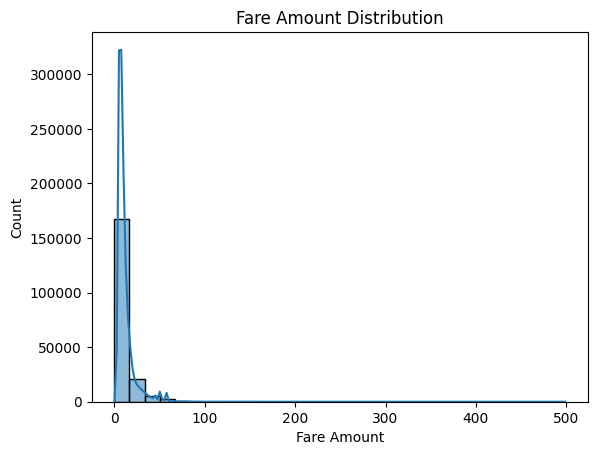

In [40]:
sns.histplot(df["fare_amount"], bins=30, kde=True)
plt.title("Fare Amount Distribution")
plt.xlabel("Fare Amount")
plt.ylabel("Count")
plt.show()

There exists outliers. Data is highly rightly skewed. We will handle it later.
- Here we will use 99%ile as upper threshold
- For lower threshold, we will choose 0.01 percentile

In [41]:
df['distance_km'].describe(percentiles=[0.01 , 0.90,0.95,0.99])

count    196000.000000
mean          4.471651
std          78.977955
min           0.000000
1%            0.000000
90%           7.024392
95%          10.033819
99%          20.429507
max        8667.693178
Name: distance_km, dtype: float64

In [42]:
df[df["distance_km"] == 0].head()

,pickup_longitude,pickup_latitude,dropoff_longitude,dropoff_latitude,passenger_count,distance_km,weekday,year,monthly_quarters,Hourly_Segments,is_peak_hour,fare_amount
5,-73.969019,40.755910,-73.969019,40.755910,1,0.0,5,2011,Q1,H1,0,4.90
48,-73.993498,40.764686,-73.993498,40.764686,1,0.0,3,2013,Q1,H6,0,56.80
84,-73.975058,40.788820,-73.975058,40.788820,1,0.0,4,2009,Q3,H3,1,49.57
166,-73.992937,40.757780,-73.992937,40.757780,1,0.0,2,2014,Q1,H6,0,4.50
361,-73.928705,40.753475,-73.928705,40.753475,1,0.0,0,2009,Q3,H5,1,10.10


There exists outliers in distance_km feature also.
- 5 rows shows distance as 0, which can be data entry error or usually the ride that never happend.
- 99 %ile shows distance of 20.4 km where as max is 8667 km, so we will also handle it later.
- we will prefer percentile method over iqr , coz there are only few rows which dont effect our data

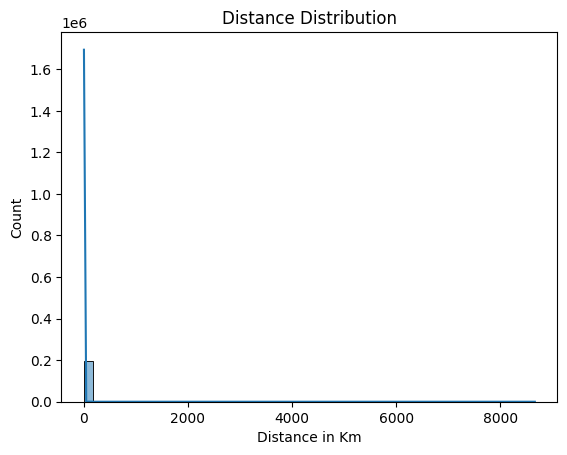

In [43]:
sns.histplot(df['distance_km'] , bins=50, kde=True)
plt.title("Distance Distribution")
plt.xlabel("Distance in Km")
plt.ylabel("Count")
plt.show()